In [ ]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA 


from cartpole_wind import cartpole_model_factory, make_envs, sample_tasks_eval

import os 

In [5]:
env_configs = sample_tasks_eval(num_envs=20)

envs = make_envs(env_configs)

In [6]:
env_configs

[{'wind_mag': -5.0},
 {'wind_mag': -4.473684210526316},
 {'wind_mag': -3.947368421052632},
 {'wind_mag': -3.4210526315789473},
 {'wind_mag': -2.8947368421052633},
 {'wind_mag': -2.368421052631579},
 {'wind_mag': -1.8421052631578947},
 {'wind_mag': -1.3157894736842106},
 {'wind_mag': -0.7894736842105265},
 {'wind_mag': -0.2631578947368425},
 {'wind_mag': 0.2631578947368416},
 {'wind_mag': 0.7894736842105257},
 {'wind_mag': 1.3157894736842106},
 {'wind_mag': 1.8421052631578947},
 {'wind_mag': 2.3684210526315788},
 {'wind_mag': 2.894736842105263},
 {'wind_mag': 3.421052631578947},
 {'wind_mag': 3.947368421052632},
 {'wind_mag': 4.473684210526315},
 {'wind_mag': 5.0}]

In [7]:
model = cartpole_model_factory()

In [13]:
checkpoint_path = os.path.join("..", "checkpoints", "cartpole_wind.pt")
checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"))

In [16]:
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

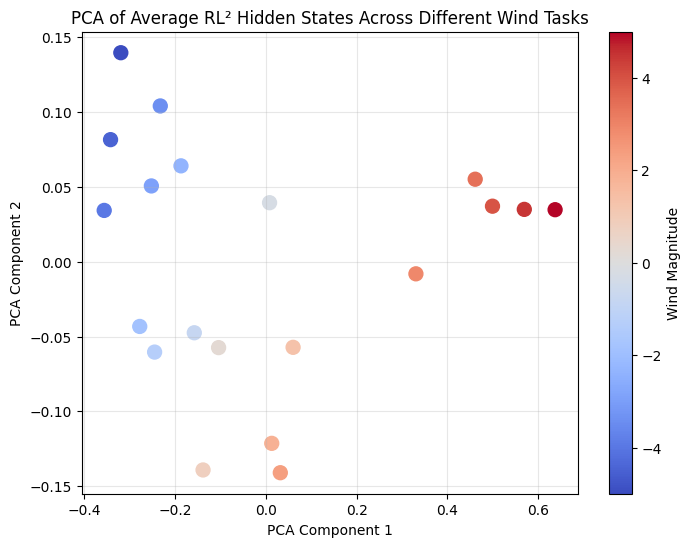

In [31]:
num_envs = len(env_configs)
steps_per_env = 3000

all_hidden_states = [] # to store (num_envs, h_dim)

# Ensure model is in the eval mode
model.eval()

# Perform rollouts
obs, _ = envs.reset() 

hidden_state = torch.zeros(1, num_envs, model.feat_extractor.h_dim)

prev_action = torch.zeros(num_envs, dtype=torch.long)
prev_reward = torch.zeros(num_envs, 1)

env_hidden_accumulator = [[] for _ in range(num_envs)]


with torch.no_grad():
    for step in range(steps_per_env):
        logits, values, hidden_state = model(
            torch.tensor(obs).view(1, num_envs, -1).float(), 
            prev_action.view(1, num_envs), 
            prev_reward.view(1, num_envs, -1).float(), 
            torch.zeros(1, num_envs, 1).float(), 
            hidden_state
        )

        current_h = hidden_state.squeeze(0).cpu().numpy() # (num_envs, h_dim)
        for i in range(num_envs):
            env_hidden_accumulator[i].append(current_h[i])

        actions = torch.argmax(logits, dim=-1) # (1, num_envs)
        actions_env = actions.squeeze(0).cpu().numpy()

        obs, reward, terminated, truncated, info = envs.step(actions_env)

        prev_action = actions 
        prev_reward = torch.tensor(reward).unsqueeze(1).float()



#Calculate Average Hidden State per Environment
avg_hidden_states = np.array([np.mean(h, axis=0) for h in env_hidden_accumulator])


pca = PCA(n_components=2)
reduced_h = pca.fit_transform(avg_hidden_states)


# Plotting
plot_name = f"CartPoleWithWind_hidden_states_{num_envs}envs.png"
save_path = os.path.join('.', plot_name)

plt.figure(figsize=(8, 6))
wind_values = [cfg['wind_mag'] for cfg in env_configs]
scatter = plt.scatter(reduced_h[:, 0], reduced_h[:, 1], c=wind_values, cmap='coolwarm', s=100)

plt.colorbar(scatter, label='Wind Magnitude')
plt.title('PCA of Average RL² Hidden States Across Different Wind Tasks')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(alpha=0.3)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()